In [1]:
%matplotlib widget

import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
import pytesseract
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Polygon
import image_utils
from get_cards_tablet import card_peek_width, card_width, get_cards, card_height

In [2]:
1080, 2280

(1080, 2280)

In [3]:
img_path = "frames_tablet/8hJd_7h.png"  #  dealer_5_cards.png"
img_np = image_utils.load_rdb(img_path)

print(f"Loaded {img_path}")
print(f"shape: {img_np.shape}, dtype: {img_np.dtype}")

Loaded frames_tablet/8hJd_7h.png
shape: (1440, 2304, 3), dtype: uint8


In [4]:
import numpy as np

def shorten_bc_da(poly_pts, t):
    a, b, c, d = poly_pts
    c_new = b + t * (c - b)        # move C toward B
    d_new = a + t * (d - a)        # move D toward A
    return np.array([a, b, c_new, d_new], dtype=poly_pts.dtype)

# Example
poly_pts = np.array([
    [1099, 419.  ],
    [1023, 462.  ],
    [1184, 565],
    [1262, 520 ]
], dtype=np.float32)

result = shorten_bc_da(poly_pts, t=1.47)
print(result)

[[1099.       419.     ]
 [1023.       462.     ]
 [1259.67     613.41003]
 [1338.61     567.47   ]]


In [5]:
poly_pts = np.array([
    [1100, 420],
    [1024, 463],
    [1278, 627],
    [1358, 576]
], dtype=np.float32)

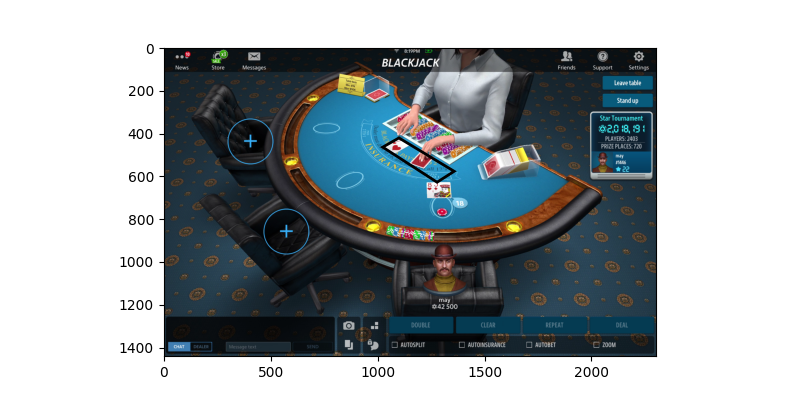

In [6]:
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(img_np)


poly = Polygon(
    poly_pts, closed=True, fill=False, ec="black", lw=2
)
ax.add_patch(poly)

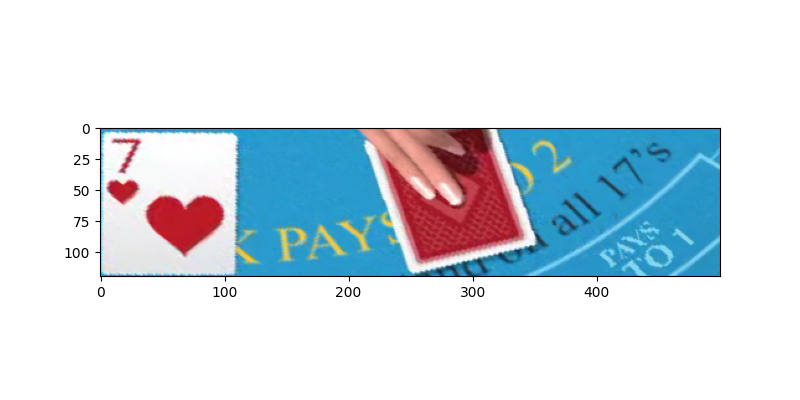

In [7]:
desired_width = card_width + card_peek_width * 10
desired_height = card_height
cards = image_utils.wrap_perspective(img_np, poly_pts, desired_width, desired_height)

f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(cards)

In [8]:
card_width, card_height

(100, 120)

In [9]:
import ocr_cards

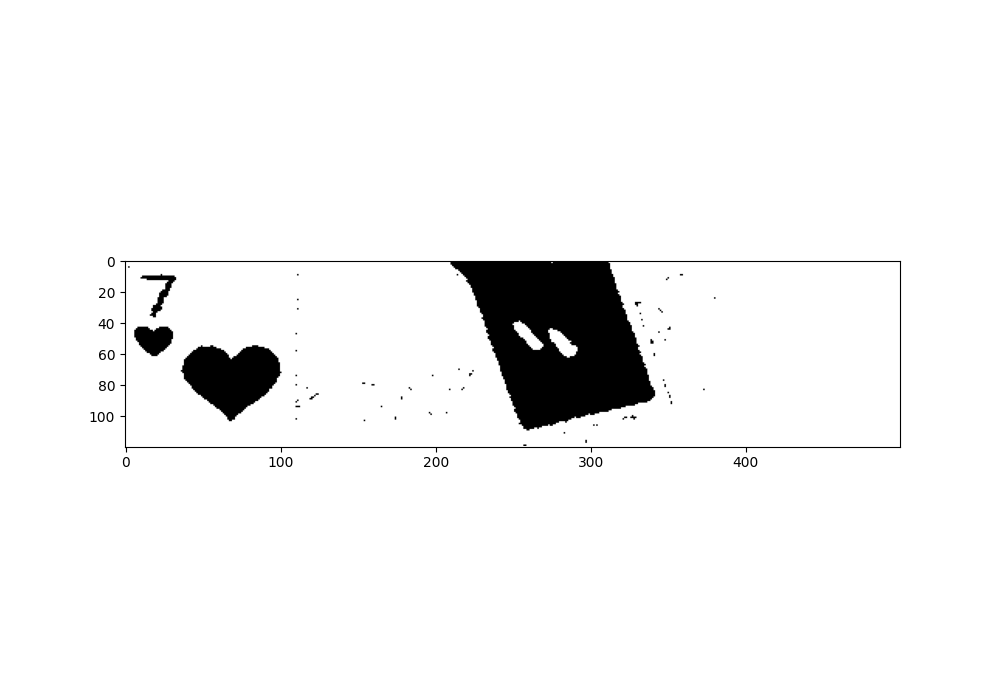

In [10]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(ocr_cards.to_bnw(cards), cmap="gray")

In [11]:
get_cards(cards)

['7h']

In [12]:
import get_cards_tablet
import pytesseract

In [13]:

matches, n_matches = image_utils.find_subimages(
    cards, get_cards_tablet._suit_templates, threshold=0.9, keys="shcd"
)
digit_images = get_cards_tablet.extract_card_values_img(cards, matches)

In [14]:
n_matches

1

In [15]:
# psm 7 - single text line
pytesseract_config = "--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789JQKA"

A


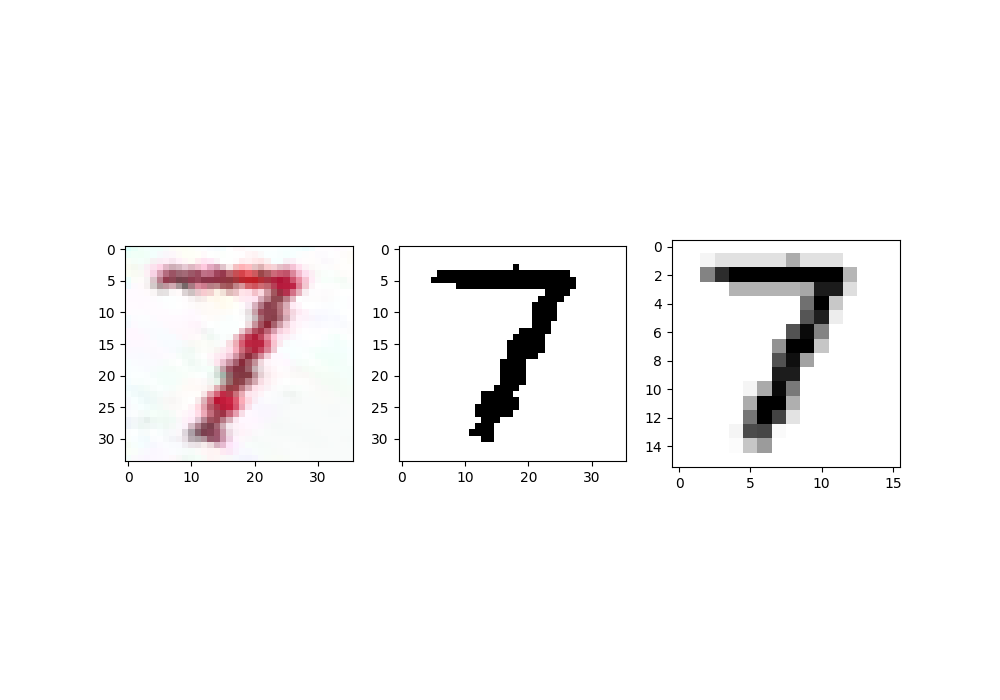

In [16]:
f, [ax0, ax1, ax2] = plt.subplots(1, 3, figsize=(10, 7))

character = digit_images["h"][0]

character_bnw = ocr_cards.to_bnw(character, threshold=128)
character_bnw_small = cv2.resize(character_bnw, (16, 16), interpolation=cv2.INTER_AREA)
print(pytesseract.image_to_string(character_bnw_small, config=pytesseract_config).strip())


ax0.imshow(character)
ax1.imshow(character_bnw, cmap="gray")
ax2.imshow(character_bnw_small, cmap="gray")


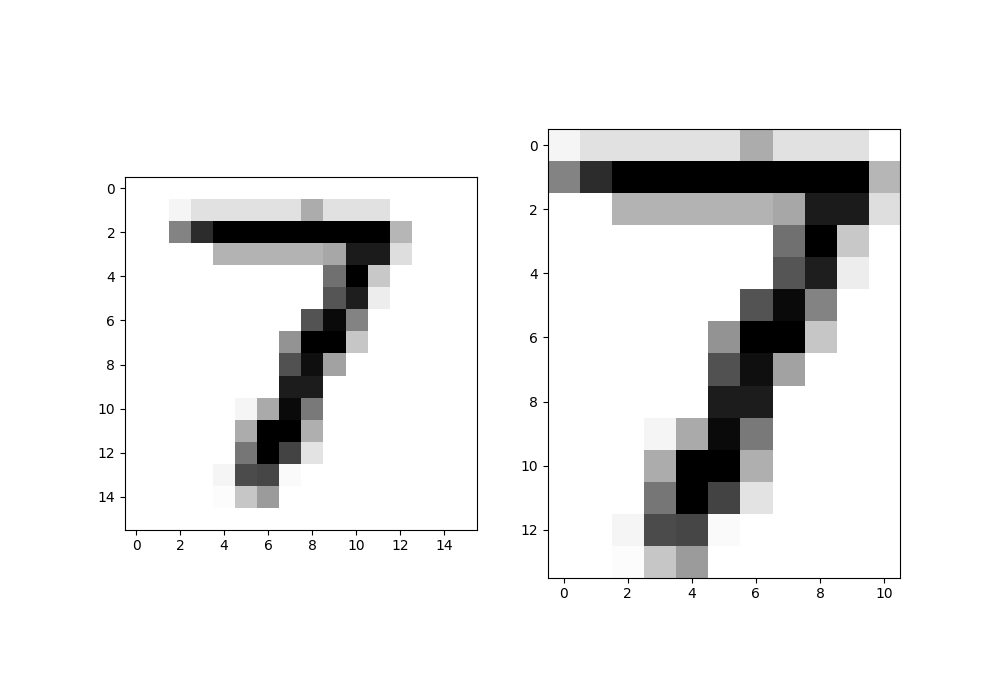

In [17]:
f, [ax0, ax1] = plt.subplots(1, 2, figsize=(10, 7))
ax0.imshow(character_bnw_small, cmap="gray")
seven_crop = character_bnw_small[1:-1, 2:-3]

ax1.imshow(seven_crop, cmap="gray")

In [18]:
# image_utils.save_rgb_png(seven_crop, "digits/7_16x16.png")

In [19]:
result.max()

np.float32(1338.61)

In [20]:
_six_16x16 = image_utils.load_rdb("digits/9_16x16.png")

In [21]:
cv2.cvtColor(_six_16x16, cv2.COLOR_RGB2GRAY)

array([[255, 255, 225, 225, 132, 105, 118, 232, 255, 255, 255],
       [255, 162,   0,   0,  75,  58,  20,  20,  90, 217, 255],
       [255,  28,   0,  67, 238, 255, 200,  47,   0,  87, 255],
       [230,  20, 142, 235, 255, 255, 255, 242,  77,   0, 222],
       [170,   0, 215, 255, 255, 255, 255, 255, 170,   0, 142],
       [205,  12,  95, 255, 255, 255, 255, 232,  47,  47, 242],
       [255, 135,   2,  42, 175, 255, 122,  12,   0,  60, 255],
       [255, 255,  68,  15,  10,   0,   0,   0,  45, 242, 255],
       [255, 255, 255, 255, 220,  83,   0,   0,  98, 255, 255],
       [255, 255, 255, 255, 255, 195,   0,  57, 235, 255, 255],
       [255, 255, 255, 255, 235,  55, 127, 230, 255, 255, 255],
       [255, 255, 255, 238,  67,   0, 255, 255, 255, 255, 255],
       [255, 255, 255, 225,  27,  40, 255, 255, 255, 255, 255],
       [255, 255, 255, 222, 105, 225, 255, 255, 255, 255, 255]],
      dtype=uint8)

In [3]:
import get_cards_tablet
import image_utils
import ocr_cards

In [4]:
dealer_cards_map = {
    "dealer_Jh7h": ["Jh", "7h"],
    "3d5h4c7cv5dAsTdQh_error": ["5d", "As", "Td", "Qh"],
    "7sQd_Jh": ["Jh"],
    "9sTd_Qh": ["Qh"],
    "8hJd_7h": ["7h"],
    "AcJd_As3s": ["As", "3s"], 
    "Ts4d_2h": ["2h"],
    "2d4h_7h": ["7h"],
    "dealer_3_cards": ["4s", "4c", "Ks"],
    "dealer_4_cards_2": ["4h", "3h", "6d", "9c"],
    "dealer_4_cards": ["6s", "9s", "As", "Jh"],
    "dealer_5_cards": ["3h", "4d", "4d", "4s", "2c"],
    "pair_bust_3": ["2c"],
    "pair_bust_before_removal": ["Qs"],
    "pair_bust": ["9c"],
    "player_blackjack": ["9h", "Kc"],
    "split_1": ["6c"],
    "split_3": ["6c", "3s", "Ad"],
    "split_5": ["Qs"],
    "Th4c_8d": ["8d"],
}

In [5]:
test_results = {}

for name, expected_result in dealer_cards_map.items():
    img_test = image_utils.load_rdb(f"frames_tablet/{name}.png")
    # cards_img = image_utils.wrap_perspective(
    #     img_test, poly_pts, card_width + card_peek_width * 10, card_height
    # )
    cards_img = get_cards_tablet.get_dealer_cards_img(img_test)
    cards = get_cards_tablet.get_cards(cards_img)
    test_results[name] = (cards == expected_result)
    if not test_results[name]:
        print(f"Test {name} failed: expected {expected_result}, got {cards}")
    else:
        print(f"Test {name} passed.")

Test dealer_Jh7h passed.
Test 3d5h4c7cv5dAsTdQh_error passed.
Test 7sQd_Jh passed.
Test 9sTd_Qh passed.
Test 8hJd_7h passed.
Test AcJd_As3s passed.
Test Ts4d_2h passed.
Test 2d4h_7h passed.
Test dealer_3_cards passed.
Test dealer_4_cards_2 passed.
Test dealer_4_cards passed.
Test dealer_5_cards passed.
Test pair_bust_3 passed.
Test pair_bust_before_removal passed.
Test pair_bust passed.
Test player_blackjack passed.
Test split_1 passed.
Test split_3 passed.
Test split_5 passed.
Test Th4c_8d passed.
